<h1 style="color: #2ecc71;">GitHub Topic & Category Exploratory Data Analysis</h1>

This notebook analyzes repository topics and their assigned categories to identify the most common topics, the most popular topics by stars, and the categories with the highest repository presence and community interest.

In [118]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Dataset Loading</h1>

This section loads the processed GitHub topic summary dataset used for topic-level and category-level analysis.

In [119]:
topic_summary = pd.read_csv(r"..\data\processed\github_topic_summary.csv")


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Dataset Overview</h1>

This section provides an initial view of the topic summary dataset and helps verify the available analytical fields before visualization.

In [120]:
topic_summary.head()


,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,10376,6720280,647.675405,17.0,194924,946664,91.235929,124630,12.011372,31670.261083,2020,2026
1,machine-learning,AI & Machine Learning,3320,2140221,644.644880,57.0,73756,277353,83.540060,51500,15.512048,71767.312048,2020,2026
2,artificial-intelligence,AI & Machine Learning,2987,5801383,1942.210579,63.0,250707,807406,270.306662,122401,40.977904,58580.565450,2020,2026
3,deep-learning,AI & Machine Learning,2676,2750349,1027.783632,154.0,165185,384322,143.618087,61634,23.032138,62784.943199,2020,2026
4,large-language-models,AI & Machine Learning,1901,6513293,3426.245660,69.0,250707,928115,488.224619,135667,71.366123,50566.749079,2020,2026


In [121]:
top_topics = topic_summary.sort_values(by="repository_count", ascending=False).head(10)
top_topics


,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,10376,6720280,647.675405,17.0,194924,946664,91.235929,124630,12.011372,31670.261083,2020,2026
1,machine-learning,AI & Machine Learning,3320,2140221,644.644880,57.0,73756,277353,83.540060,51500,15.512048,71767.312048,2020,2026
2,artificial-intelligence,AI & Machine Learning,2987,5801383,1942.210579,63.0,250707,807406,270.306662,122401,40.977904,58580.565450,2020,2026
3,deep-learning,AI & Machine Learning,2676,2750349,1027.783632,154.0,165185,384322,143.618087,61634,23.032138,62784.943199,2020,2026
4,large-language-models,AI & Machine Learning,1901,6513293,3426.245660,69.0,250707,928115,488.224619,135667,71.366123,50566.749079,2020,2026
5,automation,Automation & Agents,1869,889107,475.712681,36.0,87939,124920,66.837881,21888,11.711075,44315.478331,2020,2026
6,fastapi,Web Development,1835,622483,339.227793,47.0,74284,95626,52.112262,15186,8.275749,17572.174932,2020,2026
7,natural-language-processing,AI & Machine Learning,1757,903462,514.207171,28.0,75272,111246,63.315879,16830,9.578828,59856.219693,2020,2026
8,flask,Web Development,1715,141000,82.215743,14.0,11570,28798,16.791837,6638,3.870554,31556.724198,2020,2026
9,data-science,Data Science & Analytics,1685,466788,277.025519,20.0,47823,54745,32.489614,18194,10.797626,63311.961424,2020,2026


In [122]:
duplicate_topics = topic_summary["final_topic"].duplicated().sum()
print(f"No. of Duplicate topics:{duplicate_topics}")


No. of Duplicate topics:0


In [123]:
topic_summary.shape


(41084, 14)

<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Topic Popularity Analysis</h1>

This section identifies the topics associated with the largest number of repositories.

In [124]:
repo_count_topics = topic_summary.sort_values(
    by="repository_count", ascending=False
).head(10)


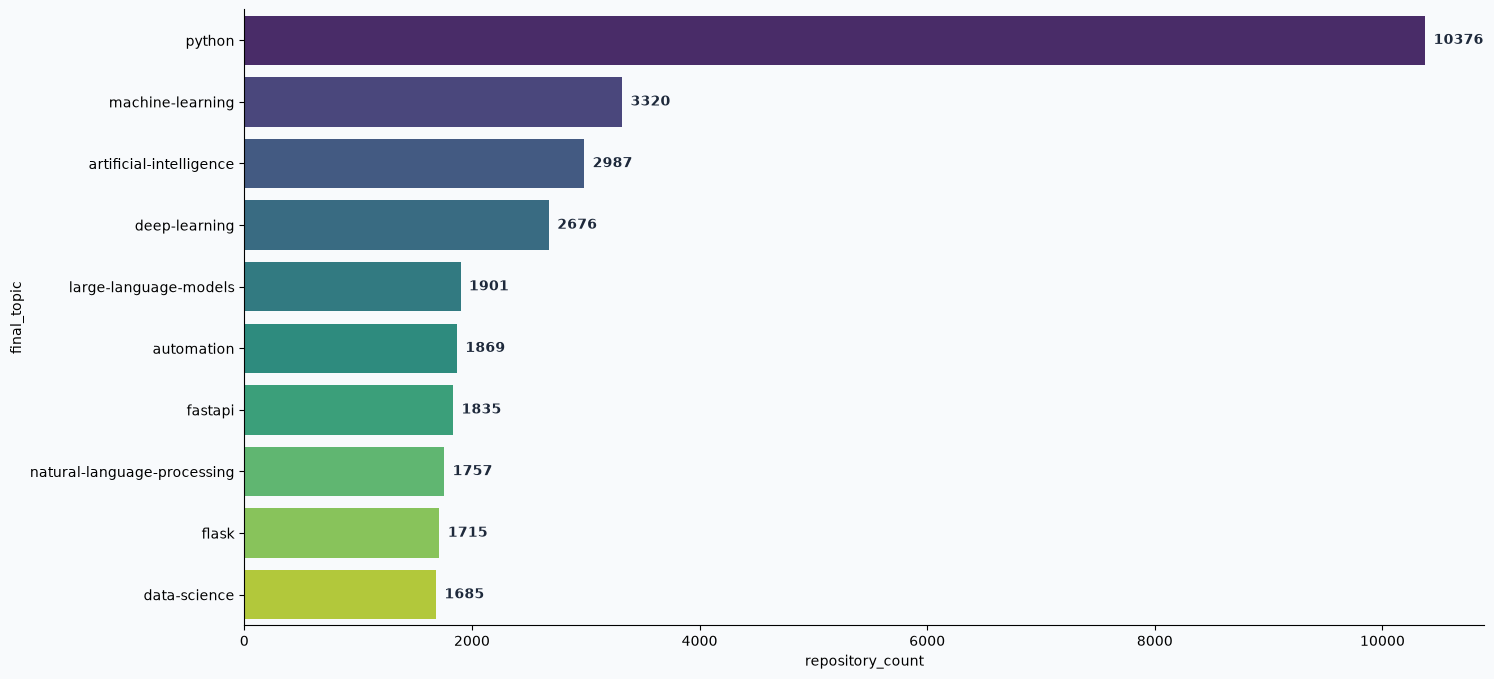

In [125]:
fig,ax=plt.subplots(figsize=(16,8),facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
bars=sns.barplot(data=repo_count_topics,x="repository_count",y="final_topic",hue="final_topic",palette="viridis",ax=ax)

for container in ax.containers:
    ax.bar_label(
        container, padding=6, fontsize=10, fontweight="bold", color="#1e293b"
    )
ax.spines[["top","right"]].set_visible(False)
plt.show()

**What does this show?**

This chart ranks the topics based on the number of repositories associated with each topic.

**Key Insight:**

In [126]:
print(
    f"{repo_count_topics.iloc[0]['final_topic']} is the most common topic, "
    f"appearing across {int(repo_count_topics.iloc[0]['repository_count']):,} repositories."
)


python is the most common topic, appearing across 10,376 repositories.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Topic Popularity by Community Interest</h1>

This section examines which topics have accumulated the highest total number of GitHub stars, using repository stars as an indicator of community interest.

In [127]:
top_topics_stars = topic_summary.sort_values(by="total_stars", ascending=False).head(10)


In [145]:
fig = px.scatter(
    data_frame=top_topics_stars,
    x="total_stars",
    y="final_topic",
    size="repository_count",
    text="final_topic",
    labels={
        "total_stars": "Total Stars",
        "final_topic": "Topic",
        "repository_count": "Repositories",
    },
    title="Top 10 Topics by Total Stars",
    color="repository_count",
    color_continuous_scale="rainbow"

)
fig.update_traces(textposition="middle right",cliponaxis=False)
fig.update_layout(

    height=500,
    title={"x": 0.5},
    xaxis_title="Total Stars",
    yaxis_title="Topic",
    coloraxis_showscale=False,
    margin={"r": 150}
)
fig.show()


**What does this show?**

This chart compares the most-starred topics and uses bubble size to represent the number of repositories associated with each topic.

**Key Insight:**

In [129]:
print(
    f"{top_topics_stars.iloc[0]['final_topic']} has the highest total community interest, "
    f"with {int(top_topics_stars.iloc[0]['total_stars']):,} stars."
)


python has the highest total community interest, with 6,720,280 stars.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Category Distribution Analysis</h1>

This section compares the major repository categories based on the number of repositories they contain.

In [130]:
top_category_repo_count = (
    topic_summary[topic_summary["category"] != "General Python & Open Source"]
    .groupby("category")["repository_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)


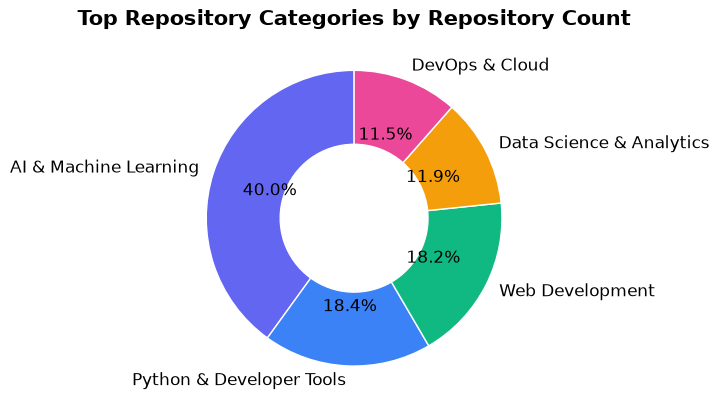

In [131]:
plt.pie(
    top_category_repo_count["repository_count"],
    labels=top_category_repo_count["category"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12},
    wedgeprops={"width": 0.5, "edgecolor": "white"},
    colors=["#6366f1", "#3b82f6", "#10b981", "#f59e0b", "#ec4899"],
)
plt.title(
    "Top Repository Categories by Repository Count",
    fontsize=15,
    fontweight="bold",
)
plt.show()


**What does this show?**

This chart shows the relative distribution of repositories across the major categories, excluding the broad General Python & Open Source category.

**Key Insight:**

In [132]:
print(
    f"{top_category_repo_count.iloc[0]['category']} is the largest category, "
    f"with {int(top_category_repo_count.iloc[0]['repository_count']):,} repositories."
)


AI & Machine Learning is the largest category, with 25,362 repositories.


<h1 style="color: #f4ed60; font-family: 'Courier New', monospace;">Category Community Interest Analysis</h1>

This section compares categories based on their total accumulated GitHub stars to identify the areas receiving the greatest community attention.

In [133]:
top_category_stars = (
    topic_summary.groupby("category")["total_stars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .iloc[::-1]
)
top_category_stars


category
Finance & Trading                 1384934
DevOps & Cloud                    1636476
Software Development              1867933
Cybersecurity                     2156497
Data Science & Analytics          2379624
Automation & Agents               3655230
Web Development                   5656493
Python & Developer Tools          7780049
AI & Machine Learning            50605781
General Python & Open Source    136437506
Name: total_stars, dtype: int64

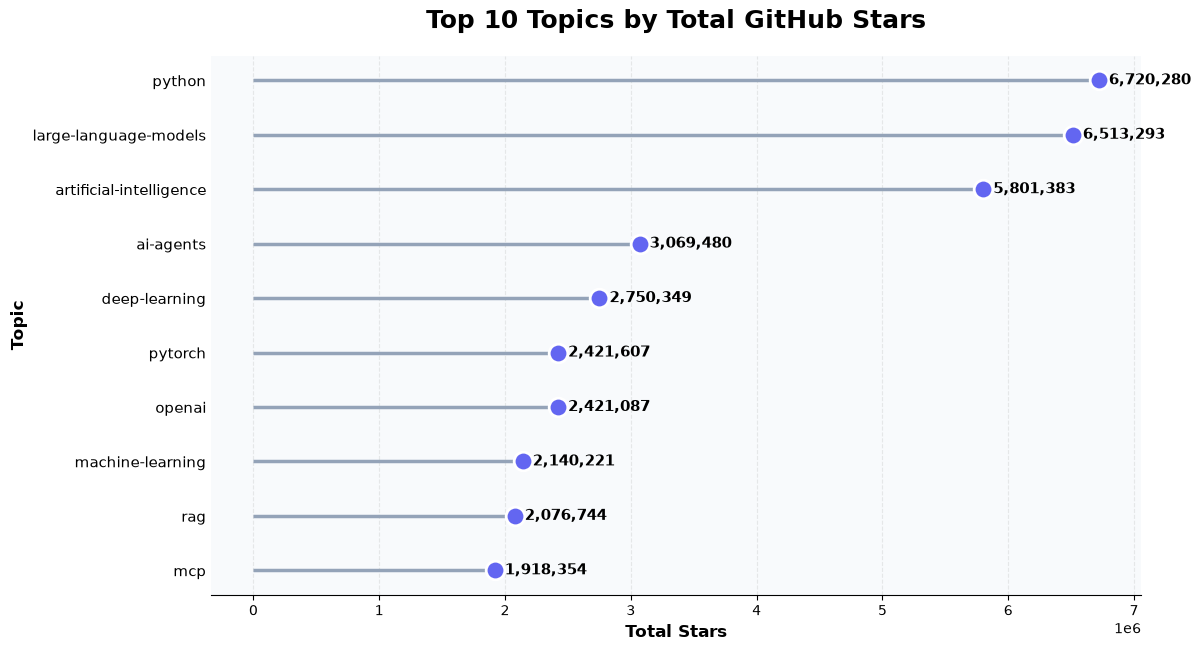

In [150]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_data = top_topics_stars.sort_values("total_stars")
ax.hlines(
    y=plot_data["final_topic"],
    xmin=0,
    xmax=plot_data["total_stars"],
    linewidth=2.5,
    color="#94a3b8",
)

ax.scatter(
    plot_data["total_stars"],
    plot_data["final_topic"],
    s=180,
    color="#6366f1",
    edgecolor="white",
    linewidth=2,
    zorder=3,
)
for y, x in zip(plot_data["final_topic"], plot_data["total_stars"]):
    ax.text(x, y, f"  {x:,.0f}", va="center", fontsize=11, fontweight="bold")
ax.set_title(
    "Top 10 Topics by Total GitHub Stars", fontsize=18, fontweight="bold", pad=20
)
ax.set_xlabel("Total Stars", fontsize=12, fontweight="bold")
ax.set_ylabel("Topic", fontsize=12, fontweight="bold")
ax.set_facecolor("#f8fafc")
fig.patch.set_facecolor("white")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=11, length=0)
ax.tick_params(axis="x", labelsize=10)
plt.show()


**What does this show?**

This chart ranks repository categories by their total number of GitHub stars, providing an indication of overall community interest across different areas.

**Key Insight:**

In [135]:
print(
    f"{top_category_stars.idxmax()} has the highest total community interest, "
    f"with {int(top_category_stars.max()):,} stars."
)


General Python & Open Source has the highest total community interest, with 136,437,506 stars.


<h1 style="color: #2ecc71;">Final Key Findings</h1>

The analysis summarizes the dominant repository topics and categories based on repository presence and community interest.

In [136]:
print("\n" + "=" * 65)
print("FINAL KEY FINDINGS")
print("=" * 65)

print(
    f"\n1. Topic Presence: {repo_count_topics.iloc[0]['final_topic']} "
    f"is the most common topic, with "
    f"{int(repo_count_topics.iloc[0]['repository_count']):,} repositories."
)

print(
    f"\n2. Topic Community Interest: {top_topics_stars.iloc[0]['final_topic']} "
    f"has the highest total stars, with "
    f"{int(top_topics_stars.iloc[0]['total_stars']):,} stars."
)

print(
    f"\n3. Category Distribution: {top_category_repo_count.iloc[0]['category']} "
    f"is the largest major category, with "
    f"{int(top_category_repo_count.iloc[0]['repository_count']):,} repositories."
)

print(
    f"\n4. Category Community Interest: {top_category_stars.idxmax()} "
    f"has the highest total stars, with "
    f"{int(top_category_stars.max()):,} stars."
)



FINAL KEY FINDINGS

1. Topic Presence: python is the most common topic, with 10,376 repositories.

2. Topic Community Interest: python has the highest total stars, with 6,720,280 stars.

3. Category Distribution: AI & Machine Learning is the largest major category, with 25,362 repositories.

4. Category Community Interest: General Python & Open Source has the highest total stars, with 136,437,506 stars.
